<a href="https://colab.research.google.com/github/fino15/Machine-Learning-Assignment/blob/main/Machine_learning_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/Project 1 - Weather Dataset.csv.csv')

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/Project 1 - Weather Dataset.csv.csv')
# df = pd.read_csv('/content/Project 1 - Weather Dataset.csv.csv')
print(" Dataset successfully loaded into 'df'!\n")

 Dataset successfully loaded into 'df'!



In [3]:
#Step 1: Data cleaning
print("Checking for missing values")
#Count missing values in each column
missing_values = df.isnull().sum()
print(missing_values)


Checking for missing values
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


In [4]:
print("\n2.Checking for deplicate rowss")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


2.Checking for deplicate rowss
Number of duplicate rows: 0


In [5]:
#Drop duplicates if any exist
if duplicate_count > 0:
  df.drop_duplicates(inplace=True)
  print("Duplicate rows dropped successfully!")
else:
  print("No duplicate rows found!")

print("\n3.Verifying structural Dta Types")
print(df.dtypes)

No duplicate rows found!

3.Verifying structural Dta Types
Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object


In [6]:
df['Weather'].value_counts()

,count
Weather,
Mainly Clear,2106
Mostly Cloudy,2069
Cloudy,1728
Clear,1326
Snow,390
Rain,306
Rain Showers,188
Fog,150
"Rain,Fog",116


In [7]:
# Function to merge/combine weather categories into major classes
def merge_weather_categories(weather_string):
    weather_string = str(weather_string).lower().strip()

    if 'thunderstorm' in weather_string:
        return 'Rain/Storm'
    elif 'freezing' in weather_string or 'snow' in weather_string or 'ice' in weather_string:
        return 'Snow/Ice'
    elif 'rain' in weather_string or 'drizzle' in weather_string:
        return 'Rain/Storm'
    elif 'fog' in weather_string or 'haze' in weather_string or 'mist' in weather_string:
        return 'Fog/Haze'
    elif 'cloudy' in weather_string:
        return 'Cloudy'
    elif 'clear' in weather_string:
        return 'Clear'
    return 'Cloudy'


#save the original weather labels
y_before = df['Weather'].copy()
# Apply the category merging logic
df['Weather_Grouped'] = df['Weather'].apply(merge_weather_categories)
#save grouped labels
y_after = df['Weather_Grouped'].copy()

print("Original Weather Categories:")
print(df['Weather'].value_counts())

print("\nGrouped Weather Categories:")
print(df['Weather_Grouped'].value_counts())

Original Weather Categories:
Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Fre

In [8]:
#Step 2:Data Transformation

from sklearn.preprocessing import LabelEncoder

#Feature Engineering

print("Performing Feature Engineering on Date/Time")
df['Date/Time']= pd.to_datetime(df['Date/Time'])

#Extract month and hour from the timestamp
df['Month'] = df['Date/Time'].dt.month
df['Hour'] = df['Date/Time'].dt.hour

#Calculate sequence changes BEFORE dropping the time metric
df['Temp_Dew_Diff'] = df['Temp_C'] - df['Dew Point Temp_C']
df['Press_Diff'] = df['Press_kPa'].diff().fillna(0)

#Drop the original text date column
df.drop('Date/Time', axis=1, inplace=True)
print("Extracted 'Month' and 'Hour' columns")

print("\nTransformed Dataset:")
print(df[['Month','Hour','Temp_C','Weather','Weather_Grouped']].head())

#Step 3: Scaling
from sklearn.preprocessing import StandardScaler
print("Data Scaling ")
#Create feature dataframe (exclude target columns)
df_features = df.drop(columns = ['Weather','Weather_Grouped'])
#Numerical columns to scale
features_to_scale =[
     'Temp_C',
    'Dew Point Temp_C',
    'Rel Hum_%',
    'Wind Speed_km/h',
    'Visibility_km',
    'Press_kPa',
    'Month',
    'Hour',
    'Temp_Dew_Diff',
    'Press_Diff'
]
#Standardize the features
scaler = StandardScaler()
df_features[features_to_scale] = scaler.fit_transform(
    df_features[features_to_scale]
)

print("\nScaled Dataset Preview")
print(df_features.head())


Performing Feature Engineering on Date/Time
Extracted 'Month' and 'Hour' columns

Transformed Dataset:
   Month  Hour  Temp_C               Weather Weather_Grouped
0      1     0    -1.8                   Fog        Fog/Haze
1      1     1    -1.8                   Fog        Fog/Haze
2      1     2    -1.8  Freezing Drizzle,Fog        Snow/Ice
3      1     3    -1.5  Freezing Drizzle,Fog        Snow/Ice
4      1     4    -1.5                   Fog        Fog/Haze
Data Scaling 

Scaled Dataset Preview
     Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  Visibility_km  \
0 -0.906815         -0.593184   1.097553        -1.259808      -1.557954   
1 -0.906815         -0.574805   1.156662        -1.259808      -1.557954   
2 -0.906815         -0.547238   1.274879        -0.914513      -1.874862   
3 -0.881146         -0.528860   1.215770        -1.029611      -1.874862   
4 -0.881146         -0.538049   1.215770        -0.914513      -1.811480   

   Press_kPa     Month      Hour  Te

# Part 2 : Training model


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [11]:
def evaluate_all_models(X, y, label_text="Experiment"):

    models = {
        "KNN": KNeighborsClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Gaussian Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Support Vector Machine": SVC(),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Neural Network": MLPClassifier(max_iter=500, random_state=42)
    }
    print(f"\n{label_text}")
    for name, model in models.items():

        scores = cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring='accuracy',
            n_jobs=-1
        )
        print(f"{name:25s}: {scores.mean()*100:.3f}% ± {scores.std()*100:.3f}%")

print(df["Weather_Grouped"].value_counts())

X = df_features.copy()

print(df_features.shape)
print(X.shape)

#Encode original weather labels
encoder_before = LabelEncoder()
y_before_encoded = encoder_before.fit_transform(y_before)

#Encode grouped weather labels
encoder_after = LabelEncoder()
y_after_encoded = encoder_after.fit_transform(y_after)

from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


#Evaluate before grouping
evaluate_all_models(X,y_before_encoded, "Figure 1:Before Grouping")
#Evaluate after grouping
evaluate_all_models(X,y_after_encoded,"Figure 2:After grouping")

Weather_Grouped
Cloudy        3797
Clear         3432
Rain/Storm     763
Snow/Ice       626
Fog/Haze       166
Name: count, dtype: int64
(8784, 10)
(8784, 10)

Figure 1:Before Grouping
KNN                      : 48.725% ± 1.923%
Logistic Regression      : 39.231% ± 0.891%
Gaussian Naive Bayes     : 32.183% ± 0.451%
Decision Tree            : 46.232% ± 1.082%
Support Vector Machine   : 45.162% ± 0.878%
Random Forest            : 56.443% ± 1.392%
Gradient Boosting        : 45.606% ± 0.840%
Neural Network           : 46.004% ± 0.695%

Figure 2:After grouping
KNN                      : 70.515% ± 1.019%
Logistic Regression      : 61.874% ± 0.260%
Gaussian Naive Bayes     : 54.338% ± 1.162%
Decision Tree            : 66.826% ± 0.763%
Support Vector Machine   : 67.145% ± 0.965%
Random Forest            : 76.628% ± 0.709%
Gradient Boosting        : 69.490% ± 0.201%
Neural Network           : 69.160% ± 1.095%


In [12]:
#rfc have a better performance, we gonna use rfc to do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': list((50, 100, 200, 300)),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

rfc_base = RandomForestClassifier(class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    estimator=rfc_base,
    param_distributions=param_distributions,
    n_iter=10,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y_after_encoded)
print(f"Highest accuracy of RFC after hyperparameter tuning: {random_search.best_score_:.3%}")
print(f"RFC Best Parameters: {random_search.best_params_}")


Highest accuracy of RFC after hyperparameter tuning: 77.277%
RFC Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 30}


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_after_encoded, test_size=0.2, random_state=42,stratify=y_after_encoded)
#Train the tuned Random Forest model
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [14]:
from sklearn.metrics import classification_report, accuracy_score

#Get the best model from the random search
best_rfc = random_search.best_estimator_

y_pred = best_rfc.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred,target_names=encoder_after.classes_))


Classification Report:
              precision    recall  f1-score   support

       Clear       0.78      0.78      0.78       686
      Cloudy       0.72      0.77      0.74       760
    Fog/Haze       0.79      0.79      0.79        33
  Rain/Storm       0.77      0.60      0.67       153
    Snow/Ice       0.81      0.76      0.79       125

    accuracy                           0.76      1757
   macro avg       0.77      0.74      0.75      1757
weighted avg       0.76      0.76      0.76      1757



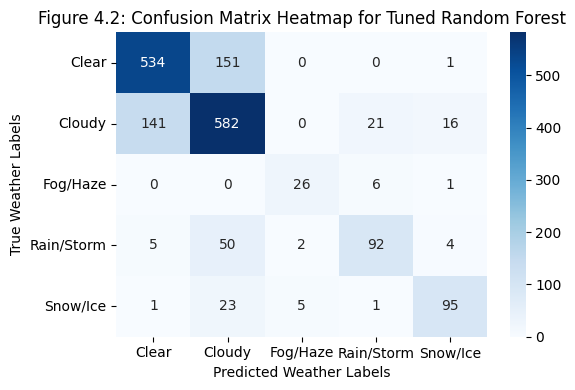

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
class_names = encoder_after.classes_
cm = confusion_matrix(y_test, y_pred)

# 2. Plot the Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names,
    yticklabels=class_names, cbar=True)

plt.title('Figure 4.2: Confusion Matrix Heatmap for Tuned Random Forest')
plt.xlabel('Predicted Weather Labels')
plt.ylabel('True Weather Labels')
plt.tight_layout()
plt.show()

